In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision
importlib.reload(collision)
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec
counter = 0

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 31 / e_mass      # now in a.u.
c6 = 5.2e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 56509.54307916515
C6 520000.0
beta (a0) 492.36682576656693
E_beta (K) 11.525197727053389
tau_beta (s) 4.164130464303455e-06


In [3]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 6e-6     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.2         # in terms of E6
num_resonances = 400        # should be odd

0.6940217440505757


found


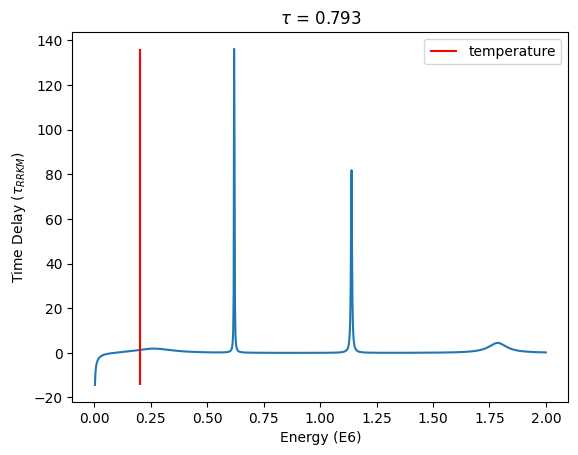

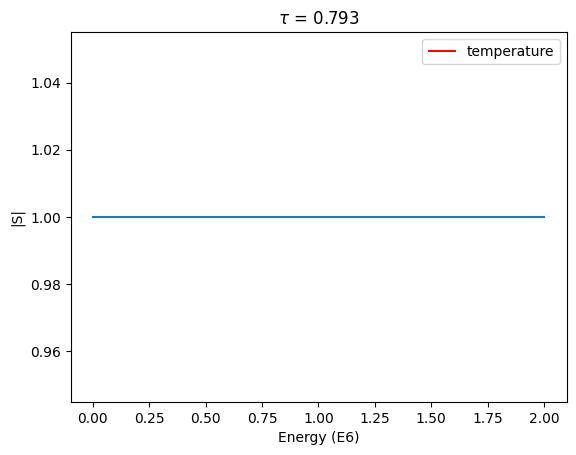

In [78]:
counter += 1
mean_x = 10
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

while True:
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
    max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)

    if time_delay > 0.75:
        print("found")
        break

energy_grid = np.linspace(0, 10 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid, time_delays)
plt.vlines(temp, min(time_delays), max(time_delays), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig(f"NaK/spectrum/positive_{counter}.pdf")
plt.show()

S_mat = S_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
plt.plot(energy_grid, np.abs(S_mat))
plt.vlines(temp, min(np.abs(S_mat)), max(np.abs(S_mat)), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel("|S|")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig(f"NaK/spectrum/S_positive_{counter}.pdf")
plt.show()


found


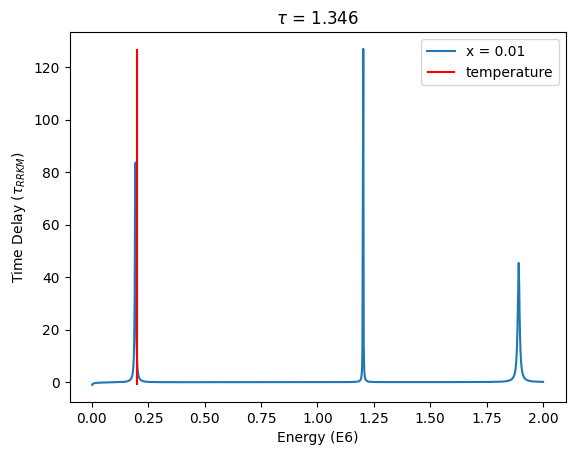

found


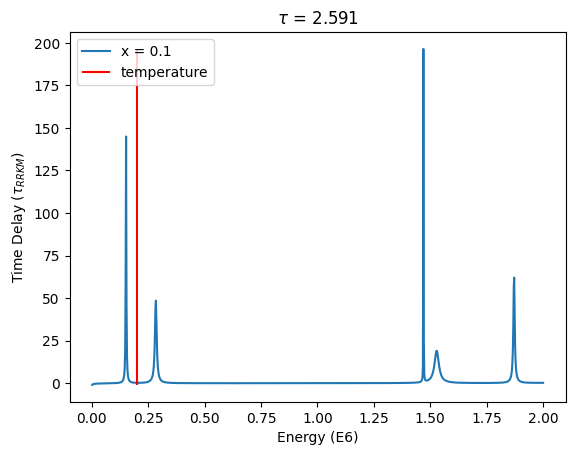

found


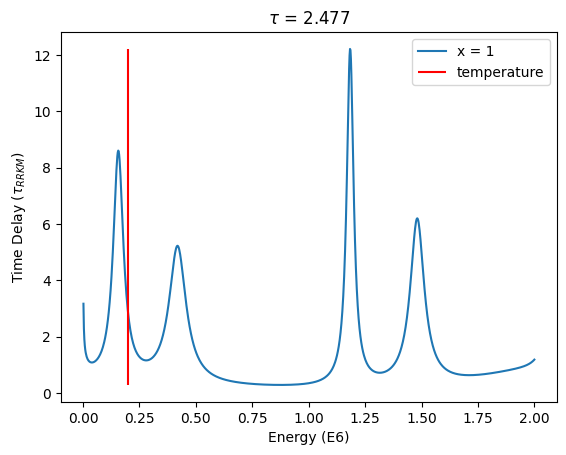

found


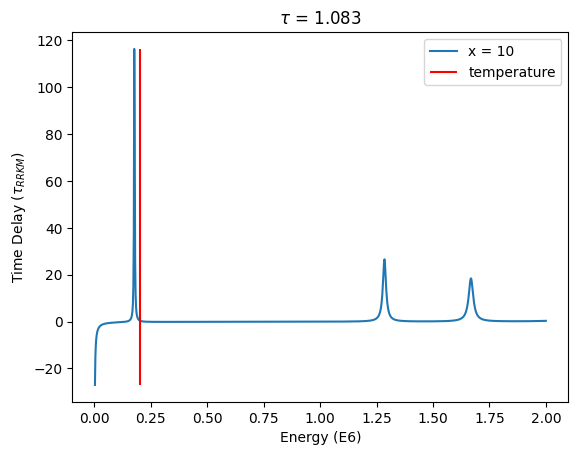

found


C:\Users\kevin\AppData\Local\Temp\ipykernel_16652\127295433.py:10: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)


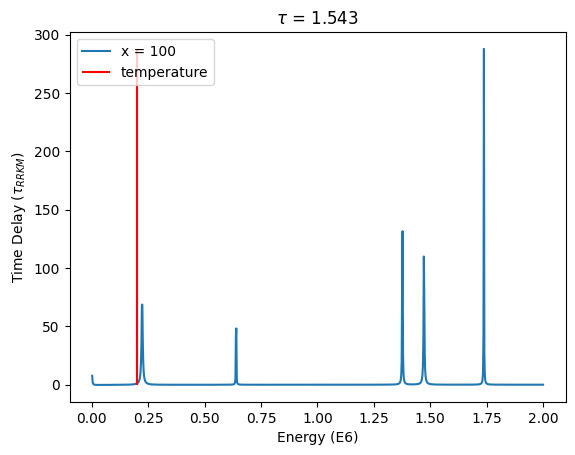

In [5]:
for mean_x in [0.01, 0.1, 1, 10, 100]:
    mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

    while True:
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
        min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
        max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)

        if time_delay > 0.75:
            print("found")
            break

    energy_grid = np.linspace(0, 10 * temp, 1000)[1:]
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    time_delays = (mean_spacing / 2 / np.pi) * time_delays
    plt.plot(energy_grid, time_delays, label=f"x = {mean_x}")

    plt.vlines(temp, min(time_delays), max(time_delays), colors="red", label="temperature")
    plt.legend()
    plt.xlabel("Energy (E6)")
    plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
    plt.title(r"$\tau$ = " + str(time_delay)[:5])
    # plt.ylim([0, 50])
    # plt.savefig(f"RbCs/spectrum/positive_{counter}.pdf")
    plt.show()


found


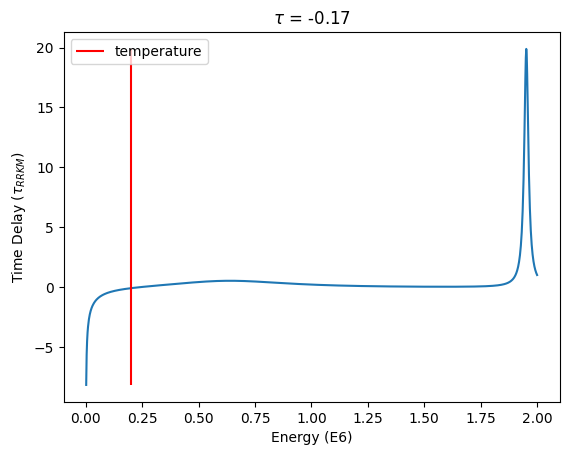

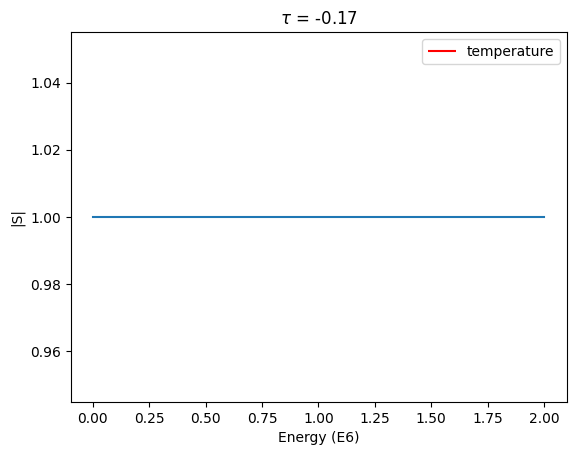

In [83]:
counter += 1
mean_x = 10
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

while True:
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
    max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)

    if time_delay < 0:
        print("found")
        break

energy_grid = np.linspace(0, 10 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid, time_delays)
plt.vlines(temp, min(time_delays), max(time_delays), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig(f"NaK/spectrum/negative_{counter}.pdf")
plt.show()

S_mat = S_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
plt.plot(energy_grid, np.abs(S_mat))
plt.vlines(temp, min(np.abs(S_mat)), max(np.abs(S_mat)), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel("|S|")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig(f"NaK/spectrum/S_negative_{counter}.pdf")
plt.show()
